In [1]:
# Basic Data Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Modeling
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch

# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error, silhouette_score

# Optional: Handling Imbalanced Data (for classification)
#from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
sns.set_palette('crest')

In [2]:
df = pd.read_csv("D:\CSci 113i proj\googleplaystore.csv")

In [3]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [5]:
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

In [6]:
df.shape

(10841, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [8]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


# **Exploratory Data Analysis**

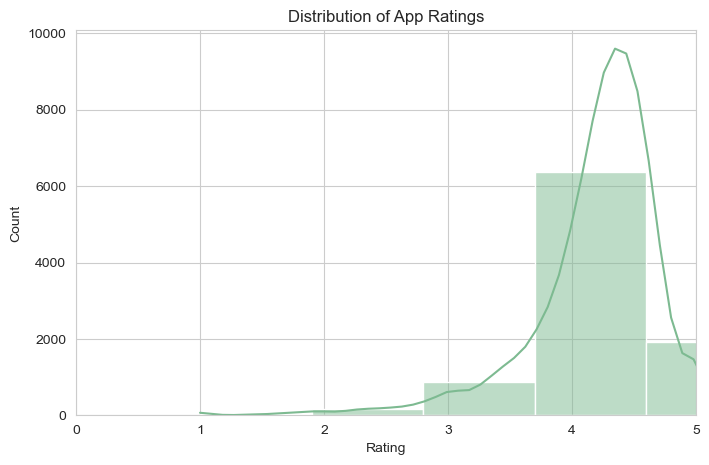

In [9]:
#Distribution of App Ratings
plt.figure(figsize=(8, 5))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.xlim(0,5)
plt.ylabel('Count')
plt.show()

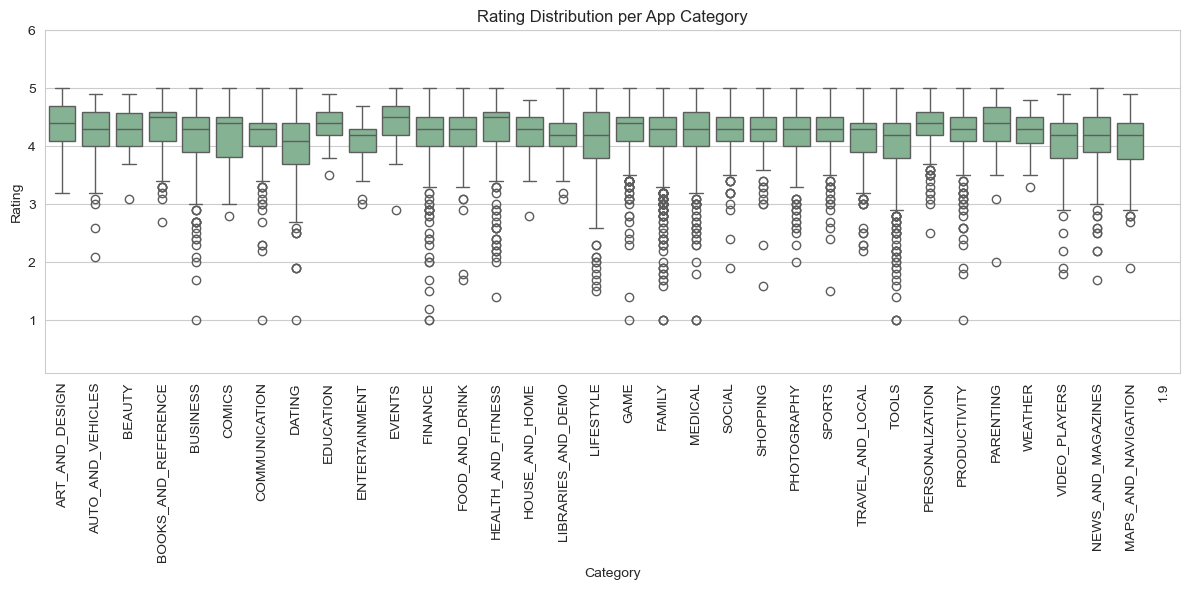

In [10]:
#Ratings by Category
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Category', y='Rating')
plt.ylim(top=6)
plt.xticks(rotation=90)
plt.title('Rating Distribution per App Category')
plt.tight_layout()
plt.show()

In [11]:
df[df['Installs'].str.contains('Free', na=False)]
df = df[~df['Installs'].str.contains('Free', na=False)]
df['Installs'] = df['Installs'].str.replace('[+,]', '', regex=True).astype(int)

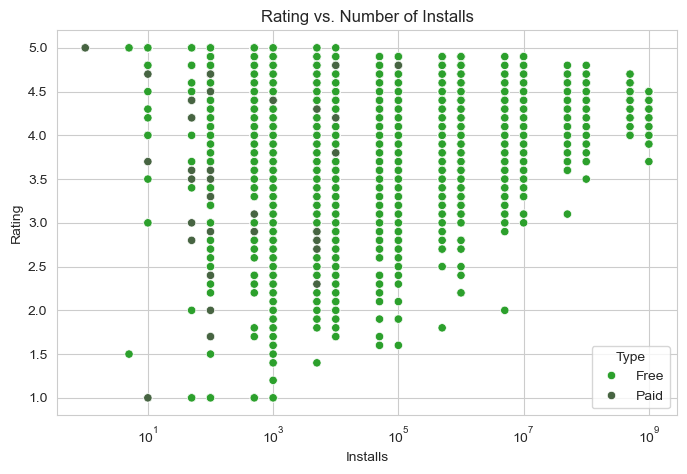

In [12]:
#Installs vs Rating
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Installs', y='Rating', hue='Type', palette=["#2ca02c", "#476442"])
plt.xscale('log')  # because install numbers can vary hugely
plt.title('Rating vs. Number of Installs')
plt.show()

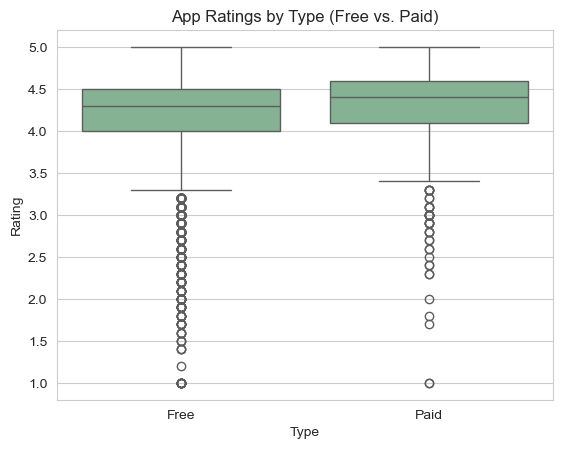

In [13]:
#Type (Free vs. Paid) Ratings
sns.boxplot(data=df, x='Type', y='Rating')
plt.title('App Ratings by Type (Free vs. Paid)')
plt.show()

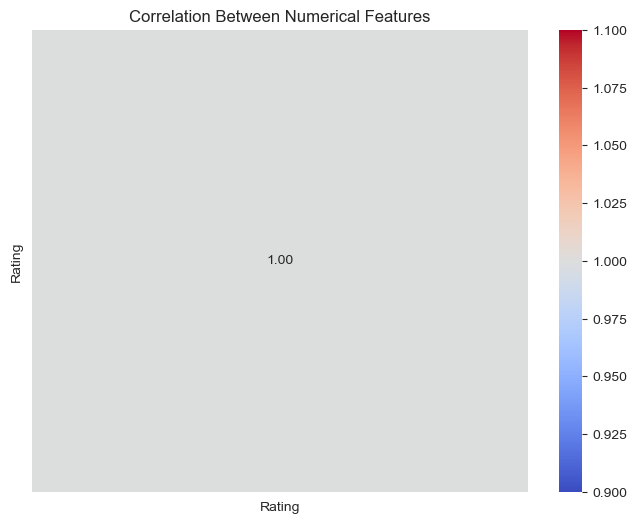

In [14]:
#Correlation Heatmap (removable)
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Numerical Features')
plt.show()

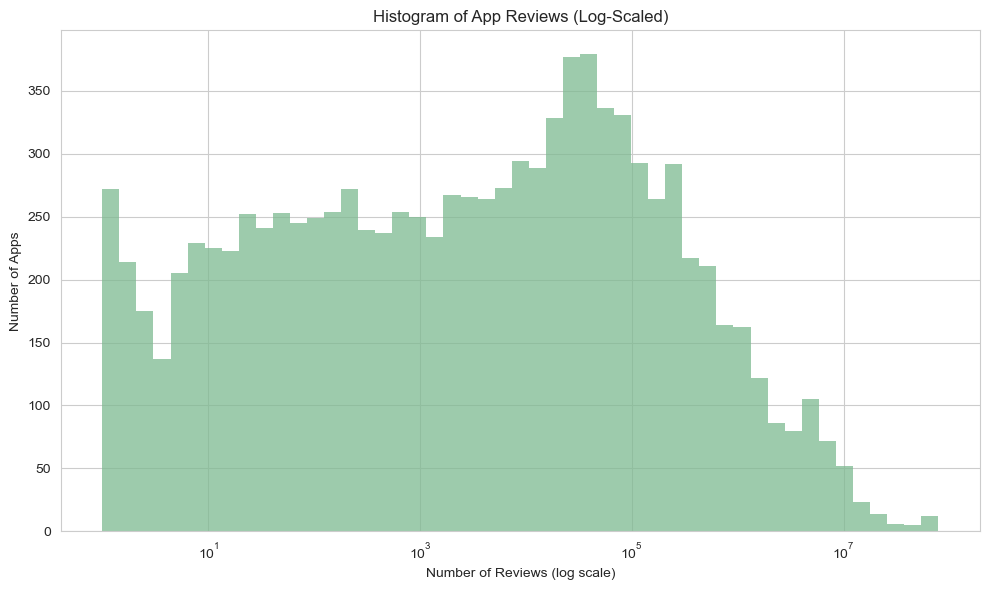

In [15]:
#Distribution of Reviews
df['Reviews'] = df['Reviews'].astype(int)
# Step 1: Filter out 0 reviews (log(0) is undefined)
filtered_reviews = df['Reviews'][df['Reviews'] > 0]

# Step 2: Create log-spaced bins
bins = np.logspace(np.log10(filtered_reviews.min()), np.log10(filtered_reviews.max()), 50)

# Step 3: Plot using log-scale
plt.figure(figsize=(10, 6))
sns.histplot(filtered_reviews, bins=bins, edgecolor='black')
plt.xscale('log')
plt.title('Histogram of App Reviews (Log-Scaled)')
plt.xlabel('Number of Reviews (log scale)')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.show()

count    8829.000000
mean       22.270540
std        22.628691
min         1.000000
25%         5.400000
50%        14.000000
75%        31.000000
max       100.000000
Name: Size, dtype: float64


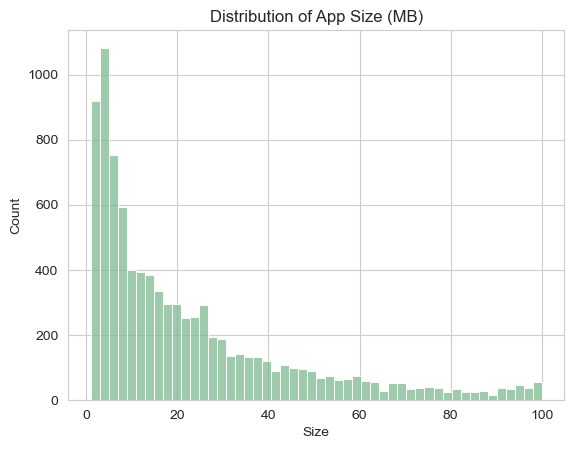

In [16]:
# Remove 'M' and convert to float (assuming 'M' = MB, float is better)
df['Size'] = df['Size'].str.replace('M', '', regex=False)
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')  # Convert to float
print(df['Size'].describe())
sns.histplot(df['Size'].dropna(), bins=50)
plt.title('Distribution of App Size (MB)')
plt.show()

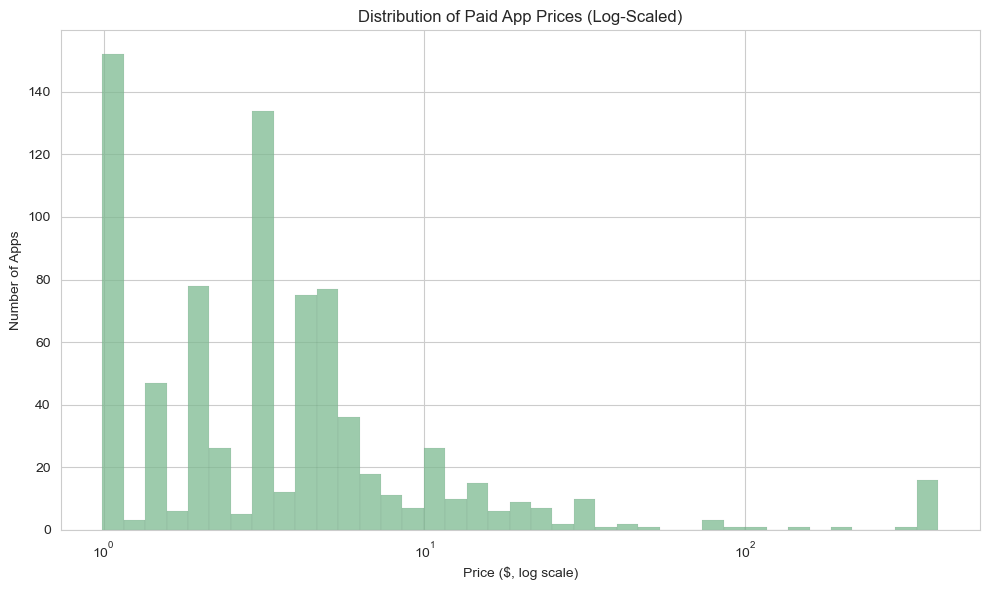

In [17]:
# Convert all to string first
df['Price'] = df['Price'].astype(str)

# Then remove dollar signs and convert to numeric
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
# Filter out 0 prices since log(0) is undefined
filtered_price = df['Price'][df['Price'] > 0]

# Use log scale histogram
plt.figure(figsize=(10, 6))
bins = np.logspace(np.log10(filtered_price.min()), np.log10(filtered_price.max()), 40)
sns.histplot(filtered_price, bins=bins, edgecolor='black')
plt.xscale('log')
plt.title('Distribution of Paid App Prices (Log-Scaled)')
plt.xlabel('Price ($, log scale)')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.show()

In [18]:
# Convert to string first in case it's already numeric
df['Installs'] = df['Installs'].astype(str)

# Remove commas and plus signs
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)

# Convert to numeric (NaN if conversion fails)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
df['Installs'].unique()
# print(df['Installs'].describe())

install_counts = df['Installs'].value_counts().sort_index()
print(install_counts)

Installs
0               15
1               67
5               82
10             386
50             205
100            719
500            330
1000           907
5000           477
10000         1054
50000          479
100000        1169
500000         539
1000000       1579
5000000        752
10000000      1252
50000000       289
100000000      409
500000000       72
1000000000      58
Name: count, dtype: int64


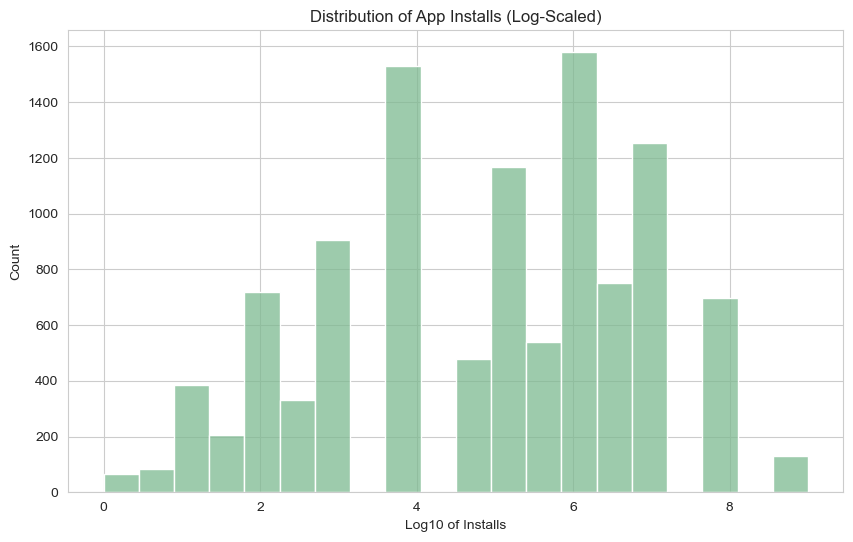

In [19]:
# Avoid log(0) by filtering out 0 installs
df_filtered = df[df['Installs'] > 0].copy()

# Create a new log-scaled column
df_filtered['Log_Installs'] = np.log10(df_filtered['Installs'])

# Plot histogram of log-scaled installs
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['Log_Installs'], bins=20)
plt.xlabel('Log10 of Installs')
plt.title('Distribution of App Installs (Log-Scaled)')
plt.show()

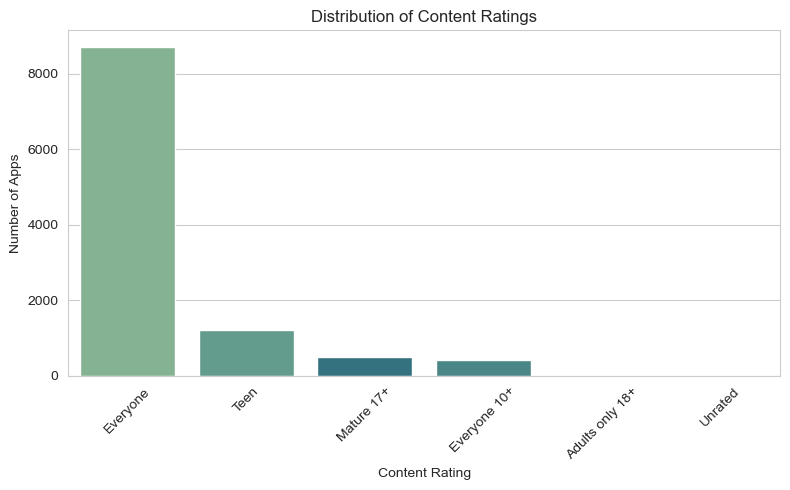

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Content Rating', hue='Content Rating', 
              order=df['Content Rating'].value_counts().index, 
              palette='crest', legend=False)

plt.title('Distribution of Content Ratings')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Rasheed\AppData\Local\Temp\ipykernel_8856\692859744.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


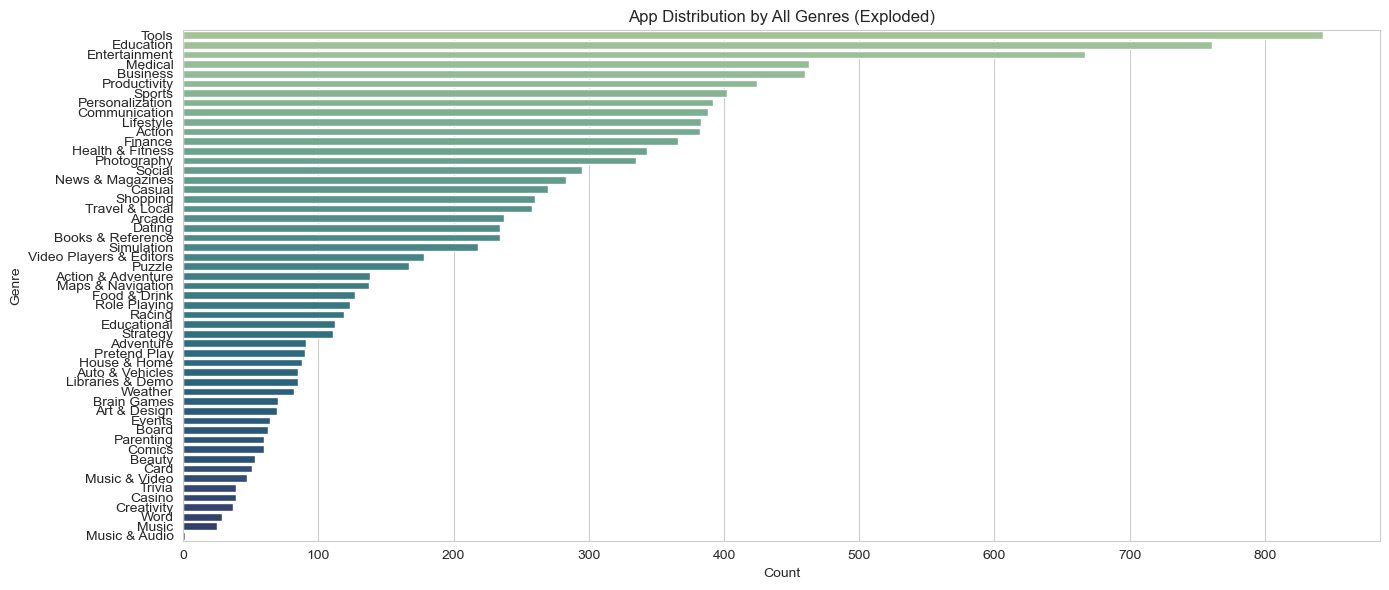

In [21]:
# Split genres into lists
df_exploded = df.assign(Genre_Split=df['Genres'].str.split(';')).explode('Genre_Split')

# Plot distribution of all genre components
plt.figure(figsize=(14,6))
sns.countplot(
    data=df_exploded,
    y='Genre_Split',
    order=df_exploded['Genre_Split'].value_counts().index,
    palette='crest',
    legend=False
)
plt.title('App Distribution by All Genres (Exploded)')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

# KMeans Clustering

In [22]:
clean_df = pd.read_csv("D:\cleanGooglePlaystore.csv")

In [23]:
clean_df

,App,Reviews,Size,Installs,isFree,Price,Content Rating_Adult,Content Rating_Everyone,Content Rating_Teen,Year Last Updated,...,Category_PERSONALIZATION,Category_PHOTOGRAPHY,Category_PRODUCTIVITY,Category_SHOPPING,Category_SOCIAL,Category_SPORTS,Category_TOOLS,Category_TRAVEL_AND_LOCAL,Category_VIDEO_PLAYERS,Category_WEATHER
0,Photo Editor & Candy Camera & Grid & ScrapBook,159,19.000000,10000.0,1,0.0,0,1,0,2018,...,0,0,0,0,0,0,0,0,0,0
1,Coloring book moana,967,14.000000,500000.0,1,0.0,0,1,0,2018,...,0,0,0,0,0,0,0,0,0,0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",87510,8.700000,5000000.0,1,0.0,0,1,0,2018,...,0,0,0,0,0,0,0,0,0,0
3,Sketch - Draw & Paint,215644,25.000000,50000000.0,1,0.0,0,0,1,2018,...,0,0,0,0,0,0,0,0,0,0
4,Pixel Draw - Number Art Coloring Book,967,2.800000,100000.0,1,0.0,0,1,0,2018,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10835,Sya9a Maroc - FR,38,53.000000,5000.0,1,0.0,0,1,0,2017,...,0,0,0,0,0,0,0,0,0,0
10836,Fr. Mike Schmitz Audio Teachings,4,3.600000,100.0,1,0.0,0,1,0,2018,...,0,0,0,0,0,0,0,0,0,0
10837,Parkinson Exercices FR,3,9.500000,1000.0,1,0.0,0,1,0,2017,...,0,0,0,0,0,0,0,0,0,0
10838,The SCP Foundation DB fr nn5n,114,21.514505,1000.0,1,0.0,1,0,0,2015,...,0,0,0,0,0,0,0,0,0,0


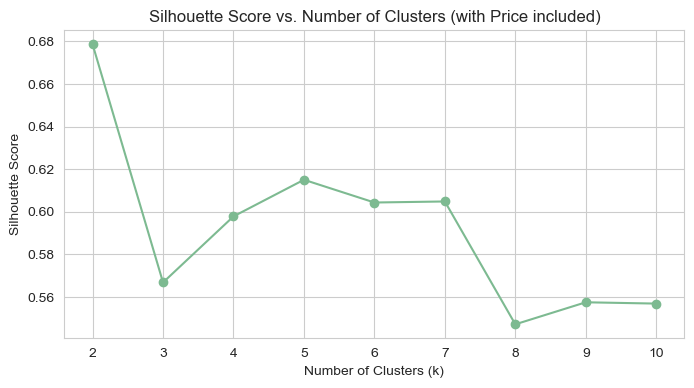

In [24]:
# STEP 2: Initial Silhouette Score Check with All Features (Price, Reviews, Size, Installs)
features = clean_df[['Price', 'Reviews', 'Size', 'Installs']]
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

silhouette_scores = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters (with Price included)')
plt.grid(True)
plt.show()

In [25]:
# STEP 3: KMeans with Price Feature (Size vs Price Visualization)
optimal_k = 2  # Based on silhouette score
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_features)
clean_df['Cluster'] = cluster_labels

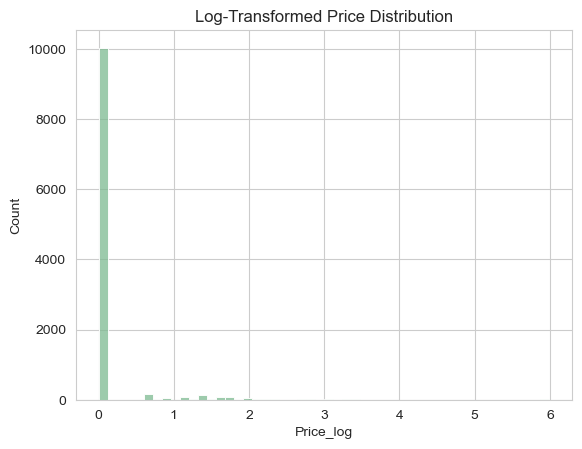

In [26]:
# Log transform and plot Price distribution
clean_df['Price_log'] = np.log1p(clean_df['Price'])
clean_df['Size_log'] = np.log1p(clean_df['Size'])
sns.histplot(clean_df['Price_log'], bins=50)
plt.title('Log-Transformed Price Distribution')
plt.show()

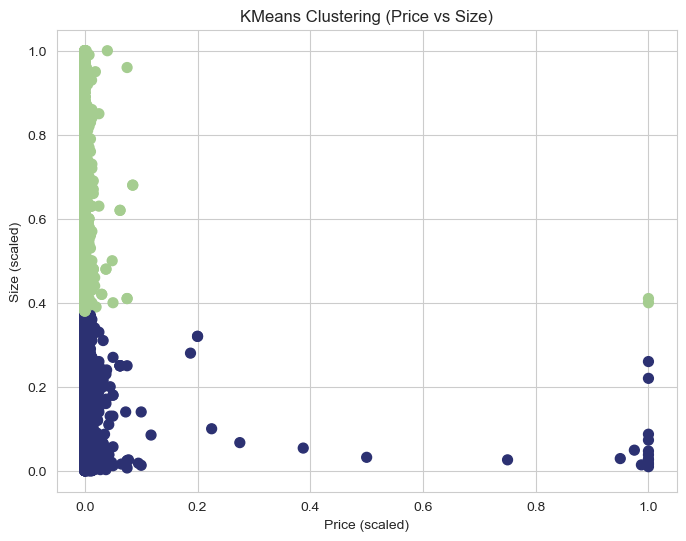

In [27]:
# Size vs Price Plot
plt.figure(figsize=(8, 6))
plt.scatter(scaled_features[:, 0], scaled_features[:, 2], c=cluster_labels, cmap='crest', s=50)
plt.xlabel('Price (scaled)')
plt.ylabel('Size (scaled)')
plt.title('KMeans Clustering (Price vs Size)')
plt.grid(True)
plt.show()

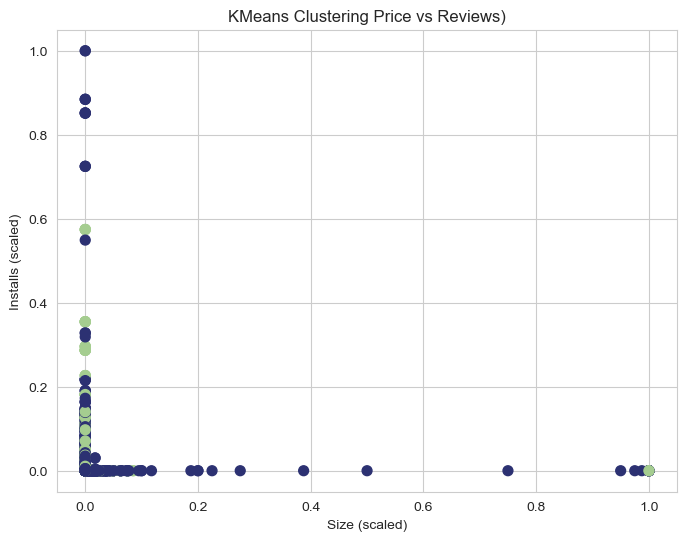

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=clean_df['Cluster'], cmap='crest', s=50)
plt.xlabel('Size (scaled)')
plt.ylabel('Installs (scaled)')
plt.title('KMeans Clustering Price vs Reviews)')
plt.grid(True)
plt.show()

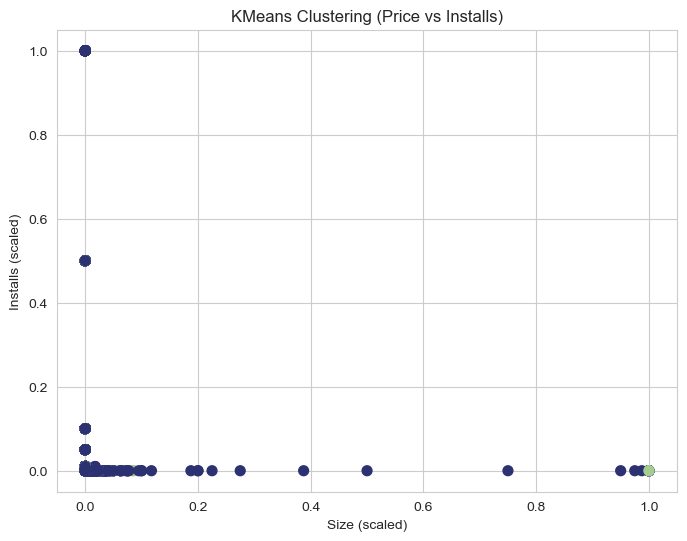

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(scaled_features[:, 0], scaled_features[:, 3], c=clean_df['Cluster'], cmap='crest', s=50)
plt.xlabel('Size (scaled)')
plt.ylabel('Installs (scaled)')
plt.title('KMeans Clustering (Price vs Installs)')
plt.grid(True)
plt.show()

In [30]:
# STEP 4: Drop Price and Recalculate KMeans
features = clean_df[['Reviews', 'Size', 'Installs']]  # Price dropped
scaled_features = scaler.fit_transform(features)
kmeans = KMeans(n_clusters=2, random_state=42)
clean_df['Cluster'] = kmeans.fit_predict(scaled_features)

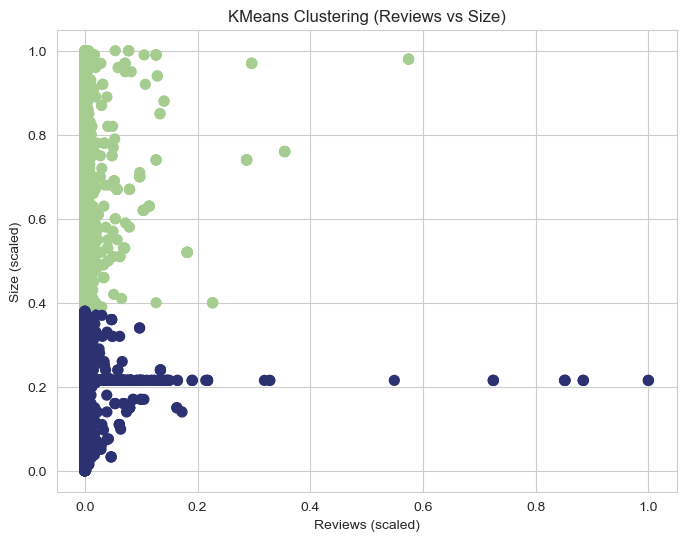

In [31]:
# STEP 5: Plot KMeans Clusters (Reviews vs Size)
plt.figure(figsize=(8, 6))
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=clean_df['Cluster'], cmap='crest', s=50)
plt.xlabel('Reviews (scaled)')
plt.ylabel('Size (scaled)')
plt.title('KMeans Clustering (Reviews vs Size)')
plt.grid(True)
plt.show()

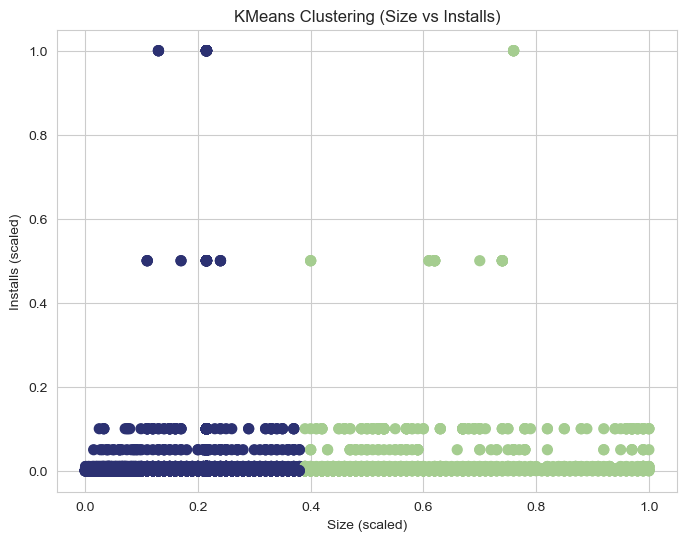

In [32]:
# STEP 6: Plot KMeans Clusters (Size vs Installs)
plt.figure(figsize=(8, 6))
plt.scatter(scaled_features[:, 1], scaled_features[:, 2], c=clean_df['Cluster'], cmap='crest', s=50)
plt.xlabel('Size (scaled)')
plt.ylabel('Installs (scaled)')
plt.title('KMeans Clustering (Size vs Installs)')
plt.grid(True)
plt.show()

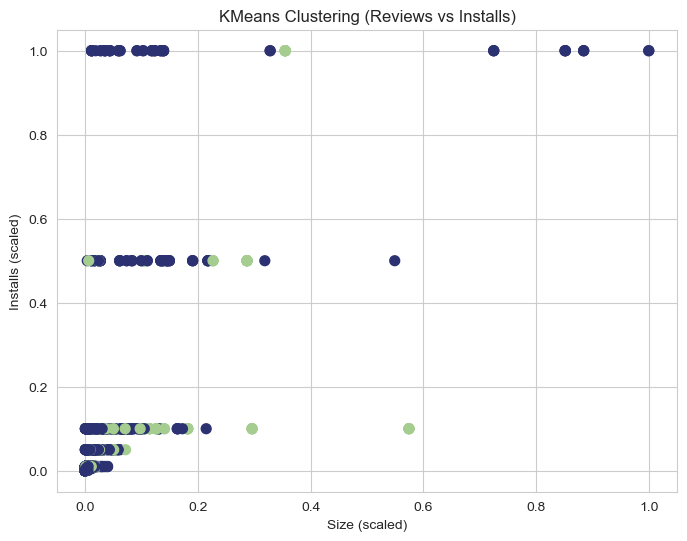

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(scaled_features[:, 0], scaled_features[:, 2], c=clean_df['Cluster'], cmap='crest', s=50)
plt.xlabel('Size (scaled)')
plt.ylabel('Installs (scaled)')
plt.title('KMeans Clustering (Reviews vs Installs)')
plt.grid(True)
plt.show()

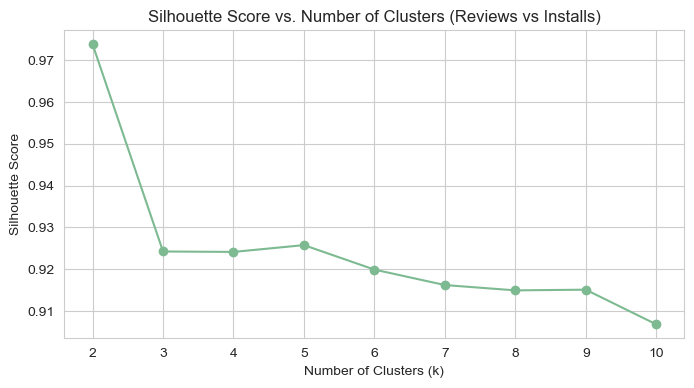

In [50]:
# STEP 7: Silhouette Score Check for Reviews vs Installs Only
features_rv_inst = clean_df[['Reviews', 'Installs']]
scaled_rv_inst = scaler.fit_transform(features_rv_inst)
silhouette_scores = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_rv_inst)
    score = silhouette_score(scaled_rv_inst, labels)
    silhouette_scores.append(score)
    
plt.figure(figsize=(8, 4))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters (Reviews vs Installs)')
plt.grid(True)
plt.show()

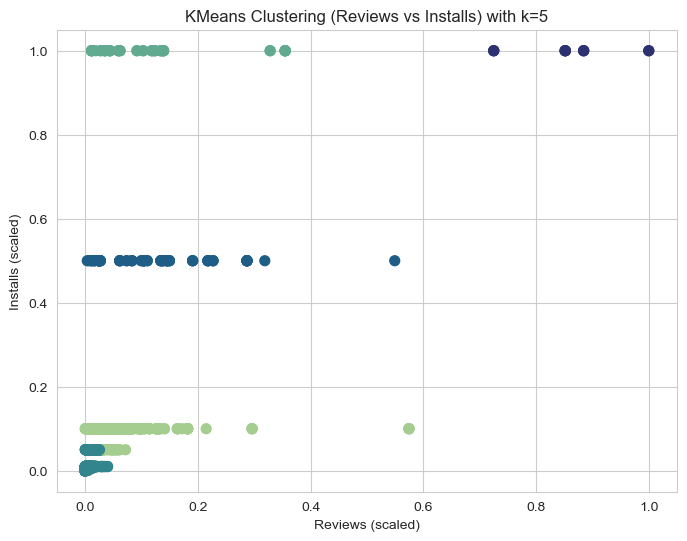

In [52]:
# STEP 8: Try Higher K for Reviews vs Installs (Interpretability Purpose)
optimal_k = 5  # Chosen for interpretability (2 was best by silhouette)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clean_df['Cluster'] = kmeans.fit_predict(scaled_rv_inst)

plt.figure(figsize=(8, 6))
plt.scatter(scaled_rv_inst[:, 0], scaled_rv_inst[:, 1], c=clean_df['Cluster'], cmap='crest', s=50)
plt.xlabel('Reviews (scaled)')
plt.ylabel('Installs (scaled)')
plt.title('KMeans Clustering (Reviews vs Installs) with k=5')
plt.grid(True)
plt.show()